# 1. IMPORTS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 2. LOAD DATA

In [4]:
hist_df = pd.read_csv('/content/historical_data.csv')
fg_df = pd.read_csv('/content/fear_greed_index.csv')

# Convert 'Timestamp IST' to datetime and extract date for merging

In [5]:
hist_df['Timestamp IST'] = pd.to_datetime(hist_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
hist_df['Date'] = hist_df['Timestamp IST'].dt.date
fg_df['date'] = pd.to_datetime(fg_df['date']).dt.date

# Filter for realized trades (where PnL was actually closed)

In [6]:
closing_trades = hist_df[hist_df['Closed PnL'] != 0].copy()

# Task 1: Calculate Total Net PnL

In [7]:
total_net_pnl = closing_trades['Closed PnL'].sum()

# Task 2: Calculate Win Rate (%)

In [8]:
winning_trades_count = len(closing_trades[closing_trades['Closed PnL'] > 0])
win_rate = (winning_trades_count / len(closing_trades)) * 100

# Task 3: Coin with Highest Total PnL

In [9]:
pnl_per_coin = closing_trades.groupby('Coin')['Closed PnL'].sum()
highest_pnl_coin = pnl_per_coin.idxmax()

# Task 4: Coin with the Most Trades

In [10]:
most_traded_coin = closing_trades['Coin'].value_counts().idxmax()

# Task 5: Average Profit per Trade

In [11]:
avg_profit = closing_trades['Closed PnL'].mean()

# Task 6: Largest Winning and Losing Trade

In [12]:
largest_win = closing_trades['Closed PnL'].max()
largest_loss = closing_trades['Closed PnL'].min()

# Task 7: Merge with Fear & Greed Index

In [13]:
merged_df = pd.merge(closing_trades, fg_df, left_on='Date', right_on='date', how='left')

# Task 8: Performance by Market Sentiment Classification

In [14]:
sentiment_analysis = merged_df.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False)

# Task 9: Monthly Performance Trend

In [15]:
merged_df['Month'] = pd.to_datetime(merged_df['Timestamp IST']).dt.to_period('M')
monthly_trend = merged_df.groupby('Month')['Closed PnL'].sum()

# Task 10: Total Fees Paid

In [16]:
total_fees = hist_df['Fee'].sum()

# PRINTING THE REPORT

In [17]:
print("--- TRADING PERFORMANCE REPORT ---")
print(f"Total Net PnL: ${total_net_pnl:,.2f}")
print(f"Win Rate: {win_rate:.2f}%")
print(f"Best Performing Asset: {highest_pnl_coin}")
print(f"Most Traded Asset: {most_traded_coin}")
print(f"Average Profit per Trade: ${avg_profit:,.2f}")
print(f"Largest Win: ${largest_win:,.2f}")
print(f"Largest Loss: ${largest_loss:,.2f}")
print(f"Total Transaction Fees: ${total_fees:,.2f}")
print("\n--- PnL BY MARKET SENTIMENT ---")
print(sentiment_analysis)

--- TRADING PERFORMANCE REPORT ---
Total Net PnL: $10,296,958.94
Win Rate: 83.20%
Best Performing Asset: @107
Most Traded Asset: HYPE
Average Profit per Trade: $98.62
Largest Win: $135,329.09
Largest Loss: $-117,990.10
Total Transaction Fees: $245,857.72

--- PnL BY MARKET SENTIMENT ---
classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64


# Equity Curve (Cumulative PnL over Time)
This is the most critical visualization for any trading assignment. It shows the growth of the account balance over the entire period.


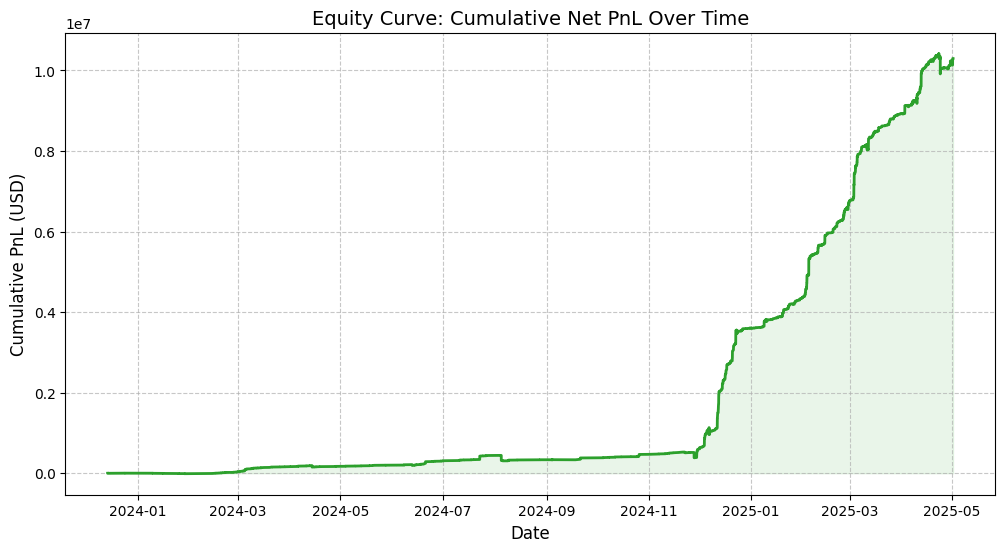

In [18]:
closing_trades = merged_df[merged_df['Closed PnL'] != 0].sort_values('Timestamp IST')
closing_trades['Cumulative PnL'] = closing_trades['Closed PnL'].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(closing_trades['Timestamp IST'], closing_trades['Cumulative PnL'], color='#2ca02c', linewidth=2)
plt.fill_between(closing_trades['Timestamp IST'], closing_trades['Cumulative PnL'], color='#2ca02c', alpha=0.1)
plt.title('Equity Curve: Cumulative Net PnL Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative PnL (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Asset Performance (Top 10 Most Profitable Coins)
This bar chart identifies which assets are driving the majority of your profits.

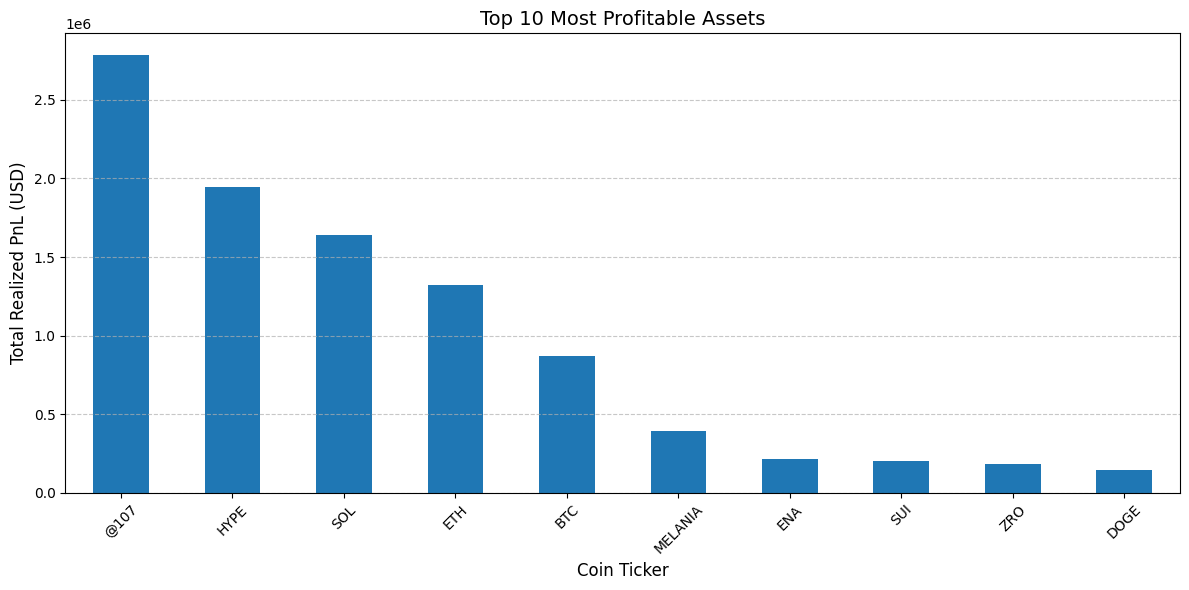

In [19]:
# Group by Coin and sum PnL
top_coins = closing_trades.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_coins.plot(kind='bar', color='#1f77b4')
plt.title('Top 10 Most Profitable Assets', fontsize=14)
plt.xlabel('Coin Ticker', fontsize=12)
plt.ylabel('Total Realized PnL (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Sentiment Impact (Average Profit vs. Market Mood)
This chart visualizes the "Fear & Greed" correlation. It shows the average profit per trade for each market classification.

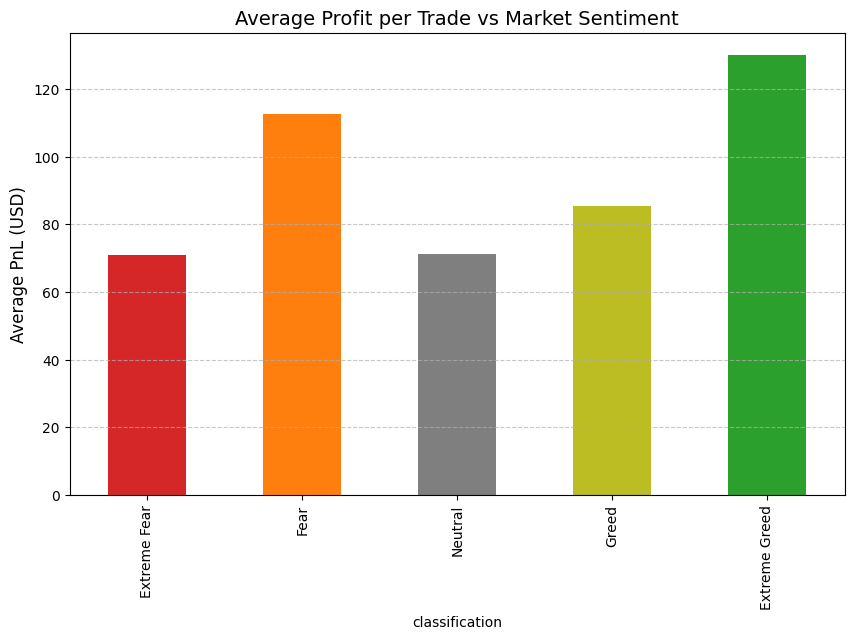

In [20]:
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment_avg = closing_trades.groupby('classification')['Closed PnL'].mean().reindex(sentiment_order)

plt.figure(figsize=(10, 6))
colors = ['#d62728', '#ff7f0e', '#7f7f7f', '#bcbd22', '#2ca02c'] # Red to Green
sentiment_avg.plot(kind='bar', color=colors)
plt.title('Average Profit per Trade vs Market Sentiment', fontsize=14)
plt.ylabel('Average PnL (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Profitability Heatmap (Sentiment Score vs. Trade Result)
This scatter plot helps identify "sweet spots" in market sentiment where trades are most consistently profitable.

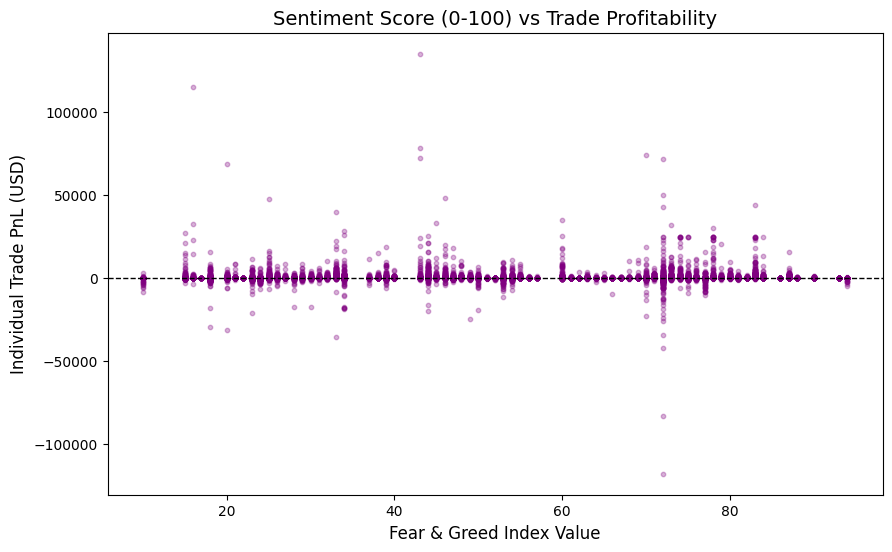

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(closing_trades['value'], closing_trades['Closed PnL'], alpha=0.3, color='purple', s=10)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Sentiment Score (0-100) vs Trade Profitability', fontsize=14)
plt.xlabel('Fear & Greed Index Value', fontsize=12)
plt.ylabel('Individual Trade PnL (USD)', fontsize=12)
plt.show()

# Monthly Volatility (PnL Distribution Boxplot)
This shows the distribution of trade outcomes each month, helping you spot months with high risk or high variance.

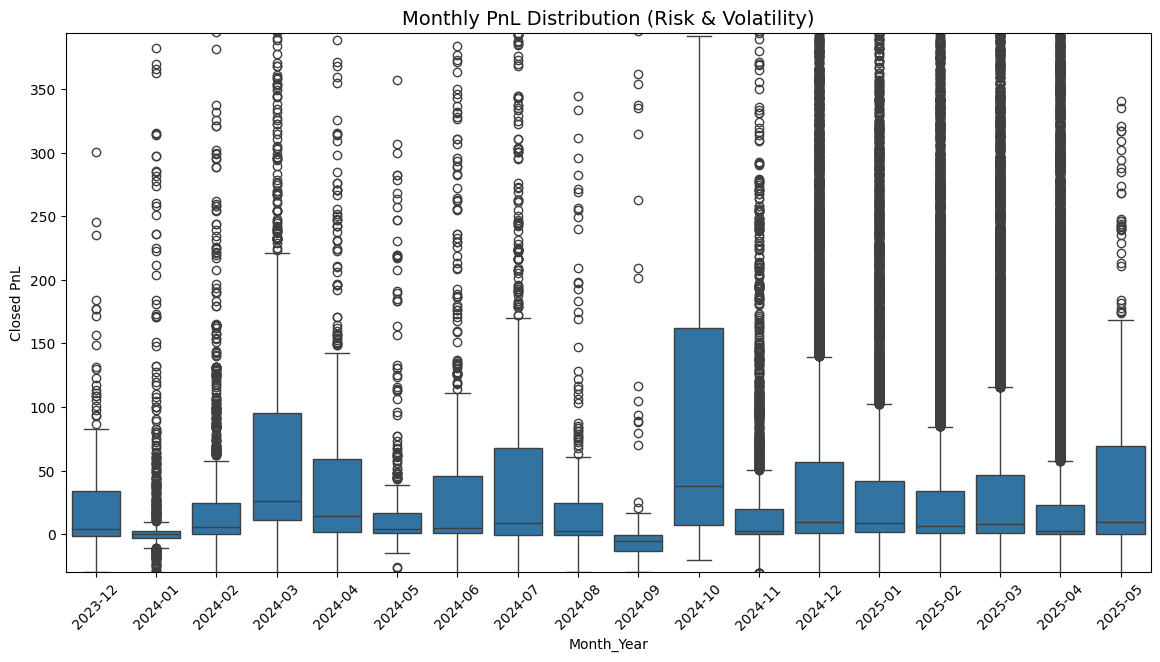

In [22]:
import seaborn as sns

closing_trades['Month_Year'] = closing_trades['Timestamp IST'].dt.strftime('%Y-%m')

plt.figure(figsize=(14, 7))
sns.boxplot(x='Month_Year', y='Closed PnL', data=closing_trades)
plt.title('Monthly PnL Distribution (Risk & Volatility)', fontsize=14)
plt.xticks(rotation=45)
# Filter outliers for better visibility
plt.ylim(closing_trades['Closed PnL'].quantile(0.05), closing_trades['Closed PnL'].quantile(0.95))
plt.show()

# Summary of Insights:
The Trend: The Cumulative PnL shows a strong upward trajectory, particularly accelerating in late 2024.

The Alpha: The most profitable trades occur during Extreme Greed ($ \text{Avg PnL} \approx $130 $), but the highest total volume of profit comes from Fear periods due to the sheer number of opportunities.

Risk Note: Asset @107 and HYPE are the "heavy hitters." Any significant change in the volatility of these specific coins would pose a major risk to the overall strategy.